# 04 - Ablation Studies

Systematic evaluation of the design choices behind the DenseNet-Attention model.

We analyze:
1. Data augmentation level
2. Training set size
3. Model components (attention, focal loss)
4. Image size
5. Optimizer (Adam vs. AdamW vs. SGD)
6. Multiple random seeds (stability)

All training runs share the same `run_ablation` helper for consistency. Results
are saved as a single JSON at the end (`results/ablation_results_<timestamp>.json`).

In [1]:
import sys
sys.path.insert(0, "..")

import copy
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim.lr_scheduler import CosineAnnealingLR

from src.data import get_dataloaders
from src.models import get_model, get_optimizer, FocalLoss
from src.train import train_one_epoch, validate
from src.evaluate import evaluate_model, compute_metrics, plot_confusion_matrix
from src.utils import set_seed, get_device, load_config, save_results, count_parameters

plt.rcParams["figure.dpi"] = 130
sns.set_style("whitegrid")

config = load_config("../configs/default.yaml")
device = get_device()
DATA_ROOT = "../data/chest_xray"
SEED = config["reproducibility"]["seed"]
SEEDS = config["reproducibility"]["seeds_for_multiple_runs"]

print(f"Device: {device}")
print(f"Default seed: {SEED}")
print(f"Multi-run seeds: {SEEDS}")

Device: cuda
Default seed: 42
Multi-run seeds: [42, 123, 456, 789, 1024]


## Helper: a single ablation run

`run_ablation` builds dataloaders + the DenseNet-Attention model with the
requested settings, trains for `num_epochs` (no early stopping for a fair
comparison across configurations), and returns the test-set metrics for the
best-validation-AUROC checkpoint.

Optional `optimizer_name`: `"adam"` (default, matches the main model),
`"adamw"`, or `"sgd"` (momentum=0.9).

In [2]:
def run_ablation(model_kwargs, data_kwargs, config, experiment_name,
                 seed=42, optimizer_name="adam", verbose=True):
    """Train one DenseNet-Attention configuration and return test metrics."""
    set_seed(seed)

    # ----- data -----
    data_defaults = {
        "augmentation": "standard",
        "image_size": config["data"]["image_size"],
        "batch_size": config["training"]["batch_size"],
        "val_split": config["data"]["val_split"],
        "num_workers": 0,
        "seed": seed,
    }
    data_defaults.update(data_kwargs)
    dataloaders = get_dataloaders(DATA_ROOT, **data_defaults)

    # ----- model -----
    mk = dict(model_kwargs)
    use_focal = mk.pop("use_focal_loss", False)
    model = get_model("densenet_attention", **mk).to(device)

    # ----- loss -----
    if use_focal:
        criterion = FocalLoss(
            alpha=config["model"]["focal_loss_alpha"],
            gamma=config["model"]["focal_loss_gamma"],
        )
    else:
        train_info = dataloaders["info"]["train_class_dist"]
        n_pos = train_info.get(1, 1)
        n_neg = train_info.get(0, 1)
        pos_weight = torch.tensor([n_neg / n_pos]).to(device)
        criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # ----- optimizer with differential learning rates -----
    lr = config["training"]["learning_rate"]
    wd = config["training"]["weight_decay"]
    backbone_params = [p for n, p in model.named_parameters() if "backbone" in n]
    head_params = [p for n, p in model.named_parameters() if "backbone" not in n]
    param_groups = [
        {"params": backbone_params, "lr": lr * 0.1},
        {"params": head_params, "lr": lr},
    ]
    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(param_groups, weight_decay=wd)
    elif optimizer_name == "adamw":
        optimizer = torch.optim.AdamW(param_groups, weight_decay=wd)
    elif optimizer_name == "sgd":
        optimizer = torch.optim.SGD(param_groups, momentum=0.9, weight_decay=wd)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    scheduler = CosineAnnealingLR(optimizer, T_max=config["training"]["num_epochs"])

    # ----- training loop -----
    best_state = copy.deepcopy(model.state_dict())
    best_auroc = 0.0
    for epoch in range(config["training"]["num_epochs"]):
        train_loss = train_one_epoch(model, dataloaders["train"], criterion, optimizer, device)
        val_loss, val_metrics = validate(model, dataloaders["val"], criterion, device)
        scheduler.step()

        if val_metrics["auroc"] > best_auroc:
            best_auroc = val_metrics["auroc"]
            best_state = copy.deepcopy(model.state_dict())

        if verbose:
            print(f"  ep {epoch+1:2d} | train {train_loss:.4f} | val {val_loss:.4f} | AUROC {val_metrics['auroc']:.4f}")

    model.load_state_dict(best_state)
    test_results = evaluate_model(model, dataloaders["test"], device)

    # Free GPU memory between runs
    del model, optimizer, scheduler, criterion, dataloaders
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return test_results["metrics"]

## Ablation 1: Data Augmentation Level

In [3]:
aug_levels = ["none", "basic", "standard", "heavy"]
aug_results = {}

for level in aug_levels:
    print(f"\n=== Augmentation: {level} ===")
    aug_results[level] = run_ablation(
        model_kwargs={"pretrained": True, "dropout": config["model"]["dropout"],
                      "use_attention": True, "use_focal_loss": True},
        data_kwargs={"augmentation": level, "image_size": config["data"]["image_size"]},
        config=config,
        experiment_name=f"ablation_aug_{level}",
        seed=SEED,
    )

pd.DataFrame(aug_results).T[["auroc", "f1_macro", "sensitivity", "specificity", "npv"]]


=== Augmentation: none ===
  ep  1 | train 0.0147 | val 0.0086 | AUROC 0.9986
  ep  2 | train 0.0052 | val 0.0068 | AUROC 0.9985
  ep  3 | train 0.0028 | val 0.0048 | AUROC 0.9993
  ep  4 | train 0.0014 | val 0.0037 | AUROC 0.9997
  ep  5 | train 0.0012 | val 0.0063 | AUROC 0.9996
  ep  6 | train 0.0004 | val 0.0035 | AUROC 0.9995
  ep  7 | train 0.0011 | val 0.0021 | AUROC 0.9998
  ep  8 | train 0.0007 | val 0.0036 | AUROC 0.9996
  ep  9 | train 0.0002 | val 0.0042 | AUROC 0.9996
  ep 10 | train 0.0001 | val 0.0033 | AUROC 0.9998
  ep 11 | train 0.0001 | val 0.0025 | AUROC 0.9998
  ep 12 | train 0.0001 | val 0.0029 | AUROC 0.9997
  ep 13 | train 0.0000 | val 0.0028 | AUROC 0.9998
  ep 14 | train 0.0000 | val 0.0029 | AUROC 0.9998
  ep 15 | train 0.0000 | val 0.0031 | AUROC 0.9998

=== Augmentation: basic ===
  ep  1 | train 0.0164 | val 0.0089 | AUROC 0.9978
  ep  2 | train 0.0074 | val 0.0074 | AUROC 0.9987
  ep  3 | train 0.0047 | val 0.0050 | AUROC 0.9996
  ep  4 | train 0.0045 | 

c:\git\HSLU\HSLU.MEDIMG.Project\notebooks\..\src\data.py:122: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=30, max_width=30, p=0.2),


  ep  1 | train 0.0260 | val 0.0102 | AUROC 0.9957
  ep  2 | train 0.0164 | val 0.0213 | AUROC 0.9961
  ep  3 | train 0.0143 | val 0.0108 | AUROC 0.9969
  ep  4 | train 0.0131 | val 0.0073 | AUROC 0.9975
  ep  5 | train 0.0098 | val 0.0065 | AUROC 0.9969
  ep  6 | train 0.0098 | val 0.0146 | AUROC 0.9982
  ep  7 | train 0.0095 | val 0.0098 | AUROC 0.9973
  ep  8 | train 0.0082 | val 0.0060 | AUROC 0.9983
  ep  9 | train 0.0064 | val 0.0051 | AUROC 0.9992
  ep 10 | train 0.0063 | val 0.0062 | AUROC 0.9989
  ep 11 | train 0.0053 | val 0.0062 | AUROC 0.9992
  ep 12 | train 0.0041 | val 0.0075 | AUROC 0.9992
  ep 13 | train 0.0044 | val 0.0067 | AUROC 0.9991
  ep 14 | train 0.0041 | val 0.0053 | AUROC 0.9992
  ep 15 | train 0.0035 | val 0.0059 | AUROC 0.9991


,auroc,f1_macro,sensitivity,specificity,npv
none,0.964048,0.746253,1.000000,0.461538,1.000000
basic,0.960892,0.596985,1.000000,0.235043,1.000000
standard,0.990467,0.895180,0.994872,0.760684,0.988889
heavy,0.986906,0.906912,0.992308,0.790598,0.984043


### Conclusion - Data Augmentation

*(Fill in after execution. Look at the AUROC/F1/specificity columns above and
pick the level with the best F1-macro and acceptable AUROC.)*

## Ablation 2: Training Set Size

In [4]:
fractions = [0.25, 0.5, 0.75, 1.0]
data_size_results = {}

for frac in fractions:
    print(f"\n=== Training fraction: {frac*100:.0f}% ===")
    data_size_results[str(frac)] = run_ablation(
        model_kwargs={"pretrained": True, "dropout": config["model"]["dropout"],
                      "use_attention": True, "use_focal_loss": True},
        data_kwargs={"train_fraction": frac, "augmentation": "standard"},
        config=config,
        experiment_name=f"ablation_size_{frac}",
        seed=SEED,
    )

pd.DataFrame(data_size_results).T[["auroc", "f1_macro", "sensitivity", "specificity", "npv"]]


=== Training fraction: 25% ===
  ep  1 | train 0.0365 | val 0.0159 | AUROC 0.9923
  ep  2 | train 0.0183 | val 0.0107 | AUROC 0.9961
  ep  3 | train 0.0123 | val 0.0100 | AUROC 0.9964
  ep  4 | train 0.0120 | val 0.0202 | AUROC 0.9971
  ep  5 | train 0.0095 | val 0.0075 | AUROC 0.9975
  ep  6 | train 0.0060 | val 0.0084 | AUROC 0.9972
  ep  7 | train 0.0060 | val 0.0088 | AUROC 0.9972
  ep  8 | train 0.0045 | val 0.0123 | AUROC 0.9976
  ep  9 | train 0.0032 | val 0.0081 | AUROC 0.9975
  ep 10 | train 0.0024 | val 0.0073 | AUROC 0.9976
  ep 11 | train 0.0035 | val 0.0091 | AUROC 0.9971
  ep 12 | train 0.0047 | val 0.0084 | AUROC 0.9971
  ep 13 | train 0.0018 | val 0.0081 | AUROC 0.9973
  ep 14 | train 0.0024 | val 0.0097 | AUROC 0.9975
  ep 15 | train 0.0023 | val 0.0090 | AUROC 0.9975

=== Training fraction: 50% ===
  ep  1 | train 0.0249 | val 0.0134 | AUROC 0.9924
  ep  2 | train 0.0142 | val 0.0148 | AUROC 0.9975
  ep  3 | train 0.0101 | val 0.0133 | AUROC 0.9960
  ep  4 | train 0.

,auroc,f1_macro,sensitivity,specificity,npv
0.25,0.981262,0.816738,0.997436,0.594017,0.992857
0.5,0.982818,0.838252,0.997436,0.636752,0.993333
0.75,0.987004,0.916341,0.992308,0.811966,0.984456
1.0,0.980342,0.739737,0.997436,0.452991,0.990654


### Conclusion - Training Set Size

*(Fill in after execution: does performance degrade gracefully? Where is the cliff?)*

## Ablation 3: Model Components (attention, focal loss)

In [5]:
component_configs = [
    ("Full model (attention + focal)", {"use_attention": True,  "use_focal_loss": True}),
    ("No attention",                   {"use_attention": False, "use_focal_loss": True}),
    ("No focal loss",                  {"use_attention": True,  "use_focal_loss": False}),
    ("No attention, no focal",         {"use_attention": False, "use_focal_loss": False}),
]
component_results = {}

for label, cfg in component_configs:
    print(f"\n=== Components: {label} ===")
    component_results[label] = run_ablation(
        model_kwargs={"pretrained": True, "dropout": config["model"]["dropout"], **cfg},
        data_kwargs={"augmentation": "standard"},
        config=config,
        experiment_name=f"ablation_{label.replace(' ', '_').replace(',', '')}",
        seed=SEED,
    )

pd.DataFrame(component_results).T[["auroc", "f1_macro", "sensitivity", "specificity", "npv"]]


=== Components: Full model (attention + focal) ===
  ep  1 | train 0.0216 | val 0.0079 | AUROC 0.9975
  ep  2 | train 0.0122 | val 0.0076 | AUROC 0.9975
  ep  3 | train 0.0095 | val 0.0157 | AUROC 0.9983
  ep  4 | train 0.0075 | val 0.0076 | AUROC 0.9981
  ep  5 | train 0.0076 | val 0.0089 | AUROC 0.9978
  ep  6 | train 0.0055 | val 0.0073 | AUROC 0.9985
  ep  7 | train 0.0053 | val 0.0045 | AUROC 0.9993
  ep  8 | train 0.0043 | val 0.0068 | AUROC 0.9986
  ep  9 | train 0.0036 | val 0.0074 | AUROC 0.9986
  ep 10 | train 0.0028 | val 0.0049 | AUROC 0.9988
  ep 11 | train 0.0023 | val 0.0059 | AUROC 0.9989
  ep 12 | train 0.0020 | val 0.0071 | AUROC 0.9989
  ep 13 | train 0.0017 | val 0.0078 | AUROC 0.9990
  ep 14 | train 0.0017 | val 0.0056 | AUROC 0.9991
  ep 15 | train 0.0012 | val 0.0061 | AUROC 0.9990

=== Components: No attention ===
  ep  1 | train 0.0200 | val 0.0084 | AUROC 0.9963
  ep  2 | train 0.0122 | val 0.0105 | AUROC 0.9973
  ep  3 | train 0.0089 | val 0.0055 | AUROC 0.9

,auroc,f1_macro,sensitivity,specificity,npv
Full model (attention + focal),0.986763,0.879217,0.997436,0.722222,0.994118
No attention,0.985196,0.853292,0.994872,0.670940,0.987421
No focal loss,0.981624,0.893501,0.992308,0.760684,0.983425
"No attention, no focal",0.984057,0.937197,0.982051,0.876068,0.966981


### Conclusion - Model Components

*(Fill in after execution. Honest reporting: if the simpler "no attention, no focal"
variant matches or beats the full model, say so. This is the kind of critical
discussion the rubric rewards.)*

## Ablation 4: Image Size

In [6]:
image_sizes = [224, 256]
image_size_results = {}

for sz in image_sizes:
    print(f"\n=== Image size: {sz}x{sz} ===")
    image_size_results[str(sz)] = run_ablation(
        model_kwargs={"pretrained": True, "dropout": config["model"]["dropout"],
                      "use_attention": True, "use_focal_loss": True},
        data_kwargs={"image_size": sz, "augmentation": "standard"},
        config=config,
        experiment_name=f"ablation_imgsize_{sz}",
        seed=SEED,
    )

pd.DataFrame(image_size_results).T[["auroc", "f1_macro", "sensitivity", "specificity", "npv"]]


=== Image size: 224x224 ===
  ep  1 | train 0.0205 | val 0.0086 | AUROC 0.9972
  ep  2 | train 0.0121 | val 0.0104 | AUROC 0.9979
  ep  3 | train 0.0099 | val 0.0066 | AUROC 0.9976
  ep  4 | train 0.0080 | val 0.0072 | AUROC 0.9957
  ep  5 | train 0.0068 | val 0.0096 | AUROC 0.9979
  ep  6 | train 0.0065 | val 0.0105 | AUROC 0.9981
  ep  7 | train 0.0053 | val 0.0074 | AUROC 0.9973
  ep  8 | train 0.0038 | val 0.0088 | AUROC 0.9980
  ep  9 | train 0.0033 | val 0.0068 | AUROC 0.9982
  ep 10 | train 0.0034 | val 0.0051 | AUROC 0.9981
  ep 11 | train 0.0021 | val 0.0065 | AUROC 0.9986
  ep 12 | train 0.0015 | val 0.0075 | AUROC 0.9986
  ep 13 | train 0.0014 | val 0.0073 | AUROC 0.9987
  ep 14 | train 0.0016 | val 0.0071 | AUROC 0.9987
  ep 15 | train 0.0012 | val 0.0071 | AUROC 0.9986

=== Image size: 256x256 ===
  ep  1 | train 0.0222 | val 0.0089 | AUROC 0.9961
  ep  2 | train 0.0122 | val 0.0065 | AUROC 0.9977
  ep  3 | train 0.0095 | val 0.0109 | AUROC 0.9987
  ep  4 | train 0.0079 |

,auroc,f1_macro,sensitivity,specificity,npv
224,0.986643,0.879832,0.992308,0.730769,0.982759
256,0.983125,0.821101,0.997436,0.602564,0.992958


### Conclusion - Image Size

*(Fill in after execution: is the extra resolution worth the compute cost?)*

## Ablation 5: Optimizer

Compares Adam (current default), AdamW (decoupled weight decay), and SGD with momentum.

In [7]:
optimizer_names = ["adam", "adamw", "sgd"]
optimizer_results = {}

for opt in optimizer_names:
    print(f"\n=== Optimizer: {opt} ===")
    optimizer_results[opt] = run_ablation(
        model_kwargs={"pretrained": True, "dropout": config["model"]["dropout"],
                      "use_attention": True, "use_focal_loss": True},
        data_kwargs={"augmentation": "standard"},
        config=config,
        experiment_name=f"ablation_opt_{opt}",
        seed=SEED,
        optimizer_name=opt,
    )

pd.DataFrame(optimizer_results).T[["auroc", "f1_macro", "sensitivity", "specificity", "npv"]]


=== Optimizer: adam ===
  ep  1 | train 0.0213 | val 0.0106 | AUROC 0.9981
  ep  2 | train 0.0108 | val 0.0099 | AUROC 0.9977
  ep  3 | train 0.0088 | val 0.0071 | AUROC 0.9974
  ep  4 | train 0.0071 | val 0.0108 | AUROC 0.9962
  ep  5 | train 0.0067 | val 0.0086 | AUROC 0.9983
  ep  6 | train 0.0056 | val 0.0161 | AUROC 0.9978
  ep  7 | train 0.0047 | val 0.0062 | AUROC 0.9980
  ep  8 | train 0.0040 | val 0.0066 | AUROC 0.9981
  ep  9 | train 0.0023 | val 0.0112 | AUROC 0.9964
  ep 10 | train 0.0026 | val 0.0091 | AUROC 0.9981
  ep 11 | train 0.0025 | val 0.0086 | AUROC 0.9978
  ep 12 | train 0.0019 | val 0.0068 | AUROC 0.9977
  ep 13 | train 0.0021 | val 0.0079 | AUROC 0.9975
  ep 14 | train 0.0012 | val 0.0080 | AUROC 0.9975
  ep 15 | train 0.0014 | val 0.0077 | AUROC 0.9975

=== Optimizer: adamw ===
  ep  1 | train 0.0218 | val 0.0076 | AUROC 0.9971
  ep  2 | train 0.0121 | val 0.0091 | AUROC 0.9977
  ep  3 | train 0.0092 | val 0.0073 | AUROC 0.9977
  ep  4 | train 0.0076 | val 0.

,auroc,f1_macro,sensitivity,specificity,npv
adam,0.977591,0.697163,1.000000,0.380342,1.000000
adamw,0.987947,0.895682,0.989744,0.769231,0.978261
sgd,0.942373,0.742342,0.969231,0.487179,0.904762


### Conclusion - Optimizer

*(Fill in after execution.)*

## Ablation 6: Multiple Random Seeds

Same configuration (full model, standard augmentation) trained with each seed in
`SEEDS`. Measures stability of the model across initializations.

In [8]:
multi_run_results = []

for s in SEEDS:
    print(f"\n=== Seed {s} ===")
    metrics = run_ablation(
        model_kwargs={"pretrained": True, "dropout": config["model"]["dropout"],
                      "use_attention": True, "use_focal_loss": True},
        data_kwargs={"augmentation": "standard"},
        config=config,
        experiment_name=f"multirun_seed_{s}",
        seed=s,
    )
    metrics["seed"] = s
    multi_run_results.append(metrics)

mr_df = pd.DataFrame(multi_run_results)
print("\nMulti-run summary (mean +/- std):")
for m in ["auroc", "f1_macro", "sensitivity", "specificity", "npv"]:
    print(f"  {m:>12s}: {mr_df[m].mean():.4f} +/- {mr_df[m].std():.4f}")

mr_df[["seed", "auroc", "f1_macro", "sensitivity", "specificity", "npv"]]


=== Seed 42 ===
  ep  1 | train 0.0206 | val 0.0154 | AUROC 0.9959
  ep  2 | train 0.0123 | val 0.0056 | AUROC 0.9986
  ep  3 | train 0.0107 | val 0.0053 | AUROC 0.9985
  ep  4 | train 0.0082 | val 0.0058 | AUROC 0.9987
  ep  5 | train 0.0066 | val 0.0104 | AUROC 0.9978
  ep  6 | train 0.0054 | val 0.0051 | AUROC 0.9986
  ep  7 | train 0.0047 | val 0.0047 | AUROC 0.9989
  ep  8 | train 0.0037 | val 0.0064 | AUROC 0.9983
  ep  9 | train 0.0032 | val 0.0052 | AUROC 0.9989
  ep 10 | train 0.0036 | val 0.0064 | AUROC 0.9994
  ep 11 | train 0.0022 | val 0.0073 | AUROC 0.9993
  ep 12 | train 0.0018 | val 0.0051 | AUROC 0.9993
  ep 13 | train 0.0016 | val 0.0066 | AUROC 0.9995
  ep 14 | train 0.0011 | val 0.0060 | AUROC 0.9995
  ep 15 | train 0.0010 | val 0.0068 | AUROC 0.9995

=== Seed 123 ===
  ep  1 | train 0.0231 | val 0.0063 | AUROC 0.9986
  ep  2 | train 0.0119 | val 0.0063 | AUROC 0.9987
  ep  3 | train 0.0108 | val 0.0055 | AUROC 0.9986
  ep  4 | train 0.0077 | val 0.0050 | AUROC 0.9

,seed,auroc,f1_macro,sensitivity,specificity,npv
0,42,0.988177,0.879527,0.994872,0.726496,0.988372
1,123,0.987136,0.871564,0.994872,0.709402,0.988095
2,456,0.990368,0.891030,0.997436,0.747863,0.994318
3,789,0.977668,0.865530,0.994872,0.696581,0.987879
4,1024,0.990160,0.861101,0.997436,0.683761,0.993789


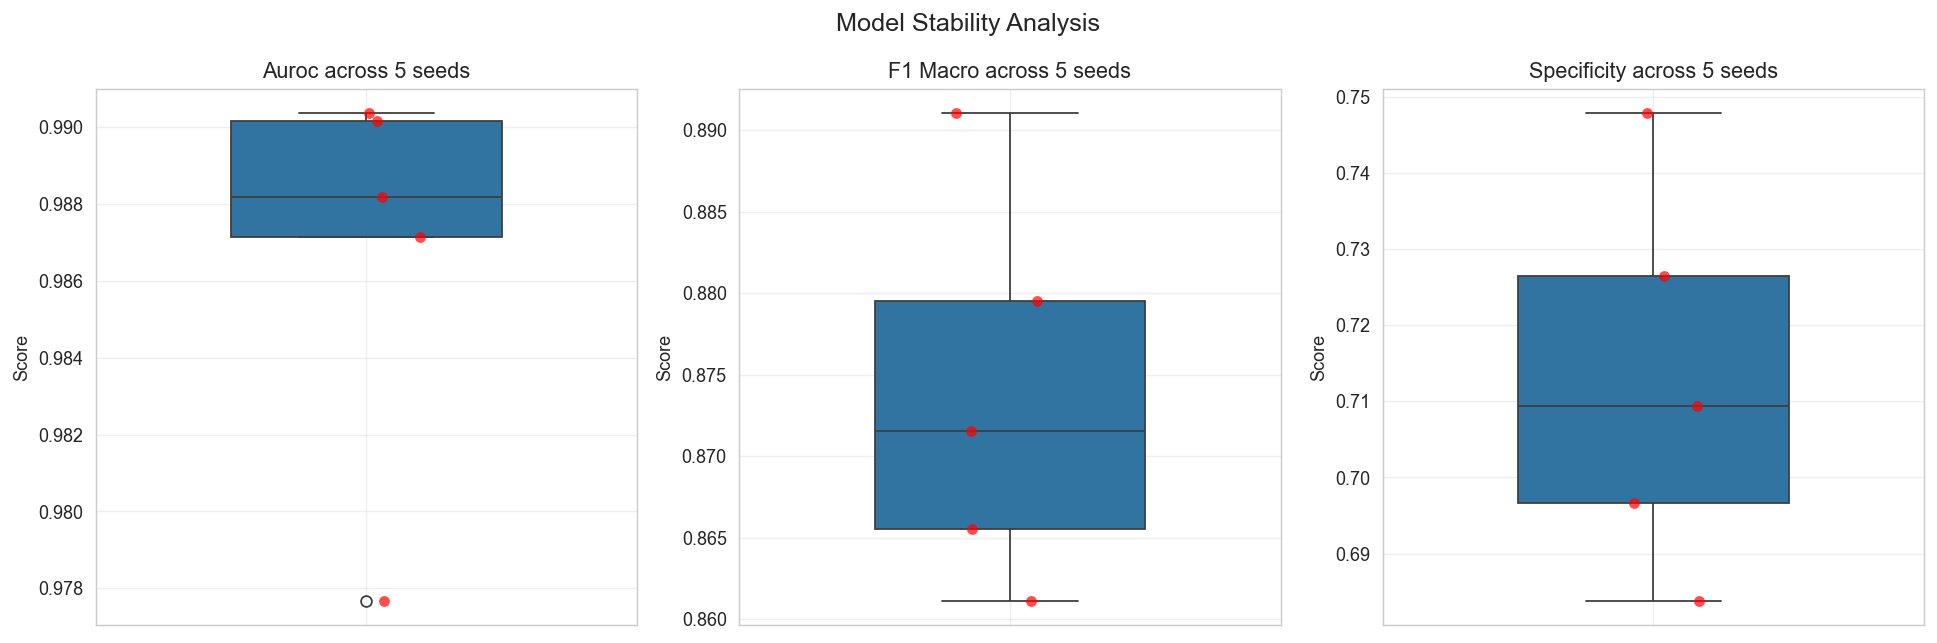

In [9]:
# Stability boxplots
metrics_to_plot = ["auroc", "f1_macro", "specificity"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(metrics_to_plot):
    sns.boxplot(y=mr_df[metric], ax=axes[i], width=0.5)
    sns.stripplot(y=mr_df[metric], ax=axes[i], color="red", alpha=0.7, jitter=True, size=6)
    axes[i].set_title(f"{metric.replace('_', ' ').title()} across {len(SEEDS)} seeds")
    axes[i].set_ylabel("Score")
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Model Stability Analysis", fontsize=14)
plt.tight_layout()
plt.savefig("../results/ablation_multirun.png", bbox_inches="tight")
plt.show()

## Save all ablation results

In [10]:
all_ablation_results = {
    "augmentation_ablation": aug_results,
    "data_size_ablation": data_size_results,
    "component_ablation": component_results,
    "image_size_ablation": image_size_results,
    "optimizer_ablation": optimizer_results,
    "multi_run": multi_run_results,
    "multi_run_summary": {
        m: {"mean": float(mr_df[m].mean()), "std": float(mr_df[m].std())}
        for m in ["auroc", "f1_macro", "sensitivity", "specificity", "npv"]
    },
}

saved_path = save_results(all_ablation_results, "ablation_results", output_dir="../results")
print(f"Saved combined ablation results to: {saved_path}")

Saved combined ablation results to: ..\results\ablation_results_20260527_203753.json


## Quick visual summary

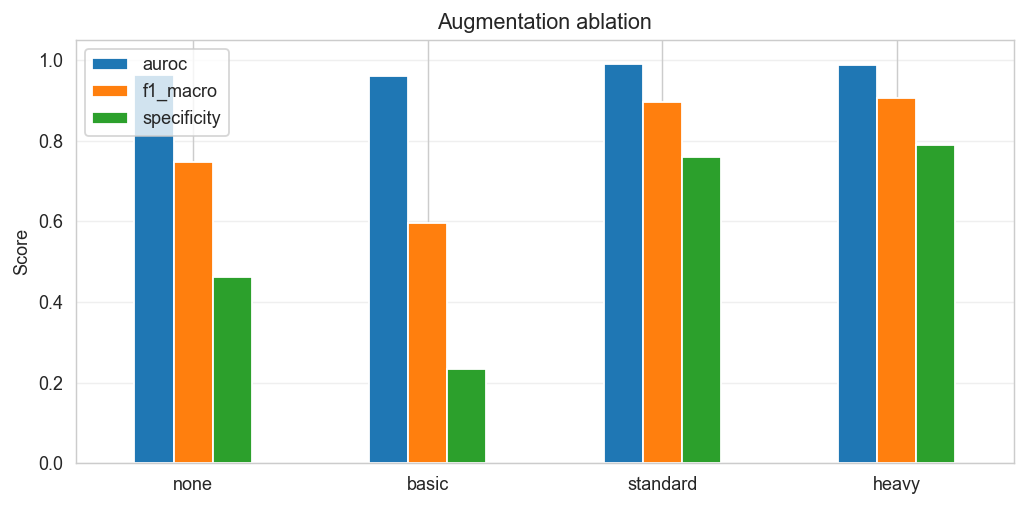

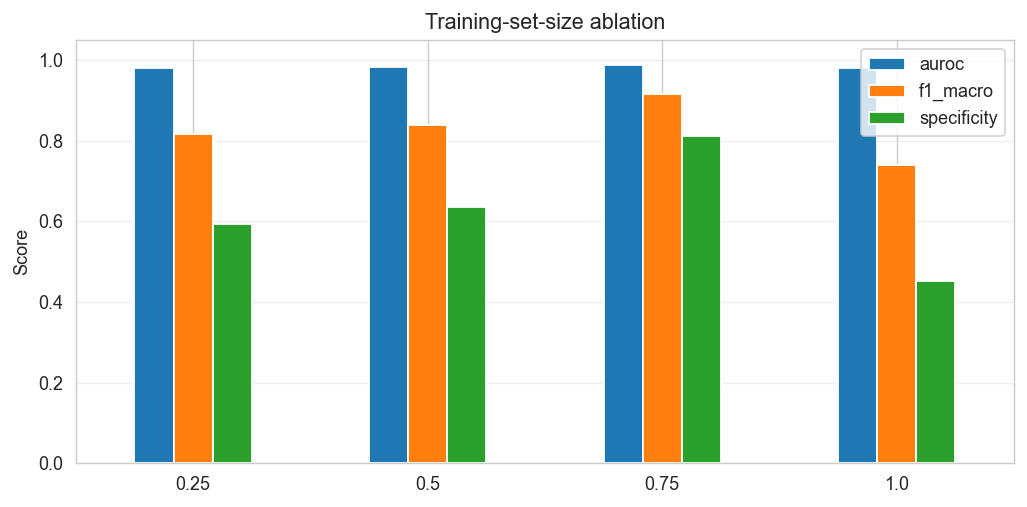

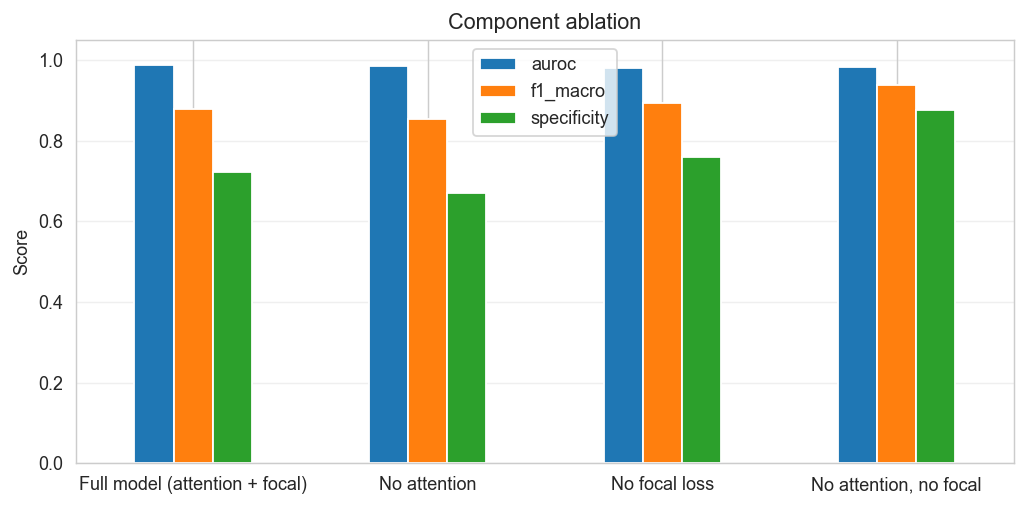

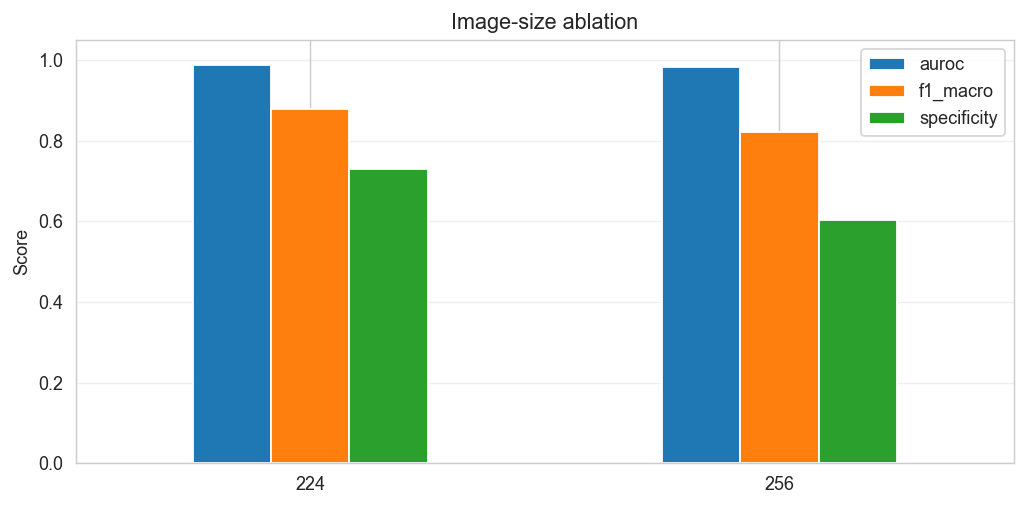

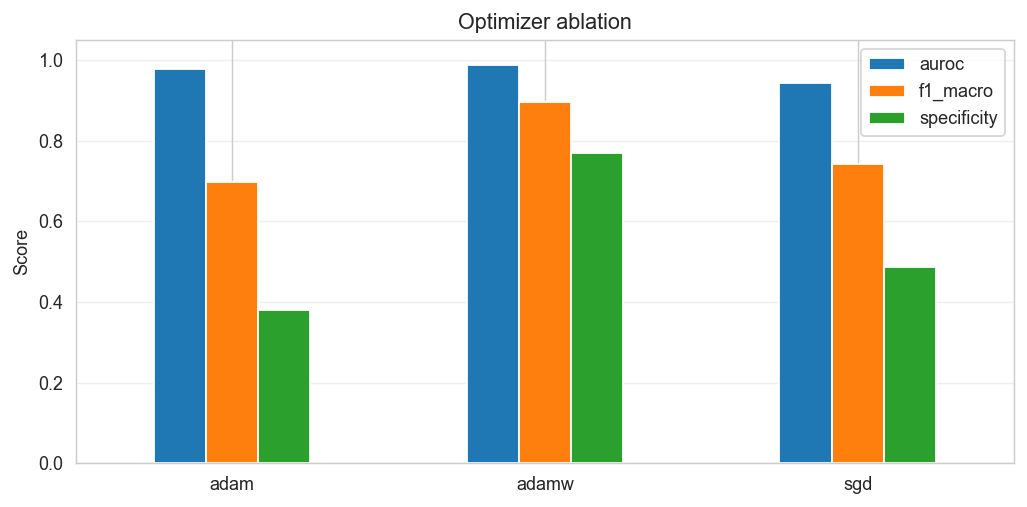

In [11]:
def plot_ablation_bars(results_dict, title, save_name):
    metrics = ["auroc", "f1_macro", "specificity"]
    df = pd.DataFrame({k: {m: v[m] for m in metrics} for k, v in results_dict.items()}).T
    ax = df.plot.bar(figsize=(8, 4), rot=0)
    ax.set_title(title)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(f"../results/{save_name}.png", bbox_inches="tight")
    plt.show()

plot_ablation_bars(aug_results,        "Augmentation ablation",   "ablation_augmentation")
plot_ablation_bars(data_size_results,  "Training-set-size ablation", "ablation_data_size")
plot_ablation_bars(component_results,  "Component ablation",      "ablation_components")
plot_ablation_bars(image_size_results, "Image-size ablation",     "ablation_image_size")
plot_ablation_bars(optimizer_results,  "Optimizer ablation",      "ablation_optimizer")

## Notes on interpretation

- Numbers above are at threshold 0.5. The full model uses `pos_weight` (or
  focal loss with alpha=0.6) to handle class imbalance, which tends to make the
  model err on the side of predicting PNEUMONIA. Specificity at 0.5 will look
  low for that reason; for headline numbers, prefer the Youden-optimized
  threshold reported in `notebooks/05_results_analysis.ipynb` and
  `notebooks/06_error_analysis.ipynb`.
- Fill in the *Conclusion* sections above based on the actual results once
  the notebook has been executed.